# 1-D Convolutional Neural Network

---
## Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PROCESSED_DIR = './processed'
OUT_DIR       = '../project/outputs/cnn'
os.makedirs(f'{OUT_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUT_DIR}/models',  exist_ok=True)

print('Config OK. Output directory:', OUT_DIR)

Using device: cpu
Config OK. Output directory: ../project/outputs/cnn


---
## Load Pre-Processed Artefacts

In [ ]:
# Feature matrices (scaled — essential for CNNs)
X_train = pd.read_csv(f'{PROCESSED_DIR}/X_train_scaled.csv', index_col=0)
X_val   = pd.read_csv(f'{PROCESSED_DIR}/X_val_scaled.csv',   index_col=0)
X_test  = pd.read_csv(f'{PROCESSED_DIR}/X_test_scaled.csv',  index_col=0)

def clean_features(df):
    df = df.apply(pd.to_numeric, errors='coerce')  # convert anything weird → NaN
    df = df.fillna(0)                              # handle NaNs
    return df.astype(np.float32)                   # force PyTorch-friendly dtype

X_train = clean_features(X_train)
X_val   = clean_features(X_val)
X_test  = clean_features(X_test)

# Regression targets
y_reg_train = pd.read_csv(f'{PROCESSED_DIR}/y_reg_train.csv', index_col=0).squeeze()
y_reg_val   = pd.read_csv(f'{PROCESSED_DIR}/y_reg_val.csv',   index_col=0).squeeze()
y_reg_test  = pd.read_csv(f'{PROCESSED_DIR}/y_reg_test.csv',  index_col=0).squeeze()

feature_names = pd.read_csv(f'{PROCESSED_DIR}/feature_list.csv')['feature'].tolist()

print('Loaded splits:')
for name, arr in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    print(f'  {name:5s}  {arr.shape[0]:6d} rows  {arr.shape[1]} features')

# Sanity checks (VERY important for CNN debugging)
print('\nDtype check:', X_train.values.dtype)
print('NaNs in train:', np.isnan(X_train.values).sum())

print(f'\nRegression target  — mean={y_reg_train.mean():.2f}, std={y_reg_train.std():.2f}')

Loaded splits:
  Train   64000 rows  49 features
  Val      8000 rows  49 features
  Test     8000 rows  49 features

Dtype check: float32
NaNs in train: 0

Regression target  — mean=89.15, std=11.57


---
## Helper: DataLoaders

The 1-D CNN expects input shape `(batch, channels, length)`.
We treat each feature as a separate channel of length 1: `(B, F, 1)`.
This lets the Conv1d kernels slide across the feature dimension.

In [3]:
def make_loader(X, y, batch_size=512, shuffle=True):
    """
    Returns a DataLoader where X has shape (B, num_features, 1)
    — the 1-D CNN channel representation.
    """
    X_t = torch.tensor(X.values, dtype=torch.float32).unsqueeze(2)   # (B, F, 1)
    y_t = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)   # (B, 1)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 512
INPUT_DIM  = X_train.shape[1]   # number of features == number of channels
print(f'Input channels (features): {INPUT_DIM}')

Input channels (features): 49


---
## CNN Architecture

In [ ]:
class TabularCNN1D(nn.Module):
    """
    1-D CNN for tabular data.

    Parameters
    ----------
    in_channels  : number of input features (treated as channels of length-1 sequence)
    conv_channels: tuple of channel sizes for each Conv1d block
    fc_dims      : tuple of hidden dims for the fully-connected head
    dropout      : dropout probability applied after each block
    output_dim   : 1 for regression or binary classification
    """
    def __init__(self,
                 in_channels,
                 conv_channels=(64, 128, 64),
                 fc_dims=(256, 64),
                 dropout=0.3,
                 output_dim=1):
        super().__init__()

        conv_blocks = []
        prev_ch = in_channels
        for ch in conv_channels:
            conv_blocks += [
                nn.Conv1d(prev_ch, ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(ch),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_ch = ch
        conv_blocks.append(nn.AdaptiveAvgPool1d(1))   # → (B, prev_ch, 1)
        self.conv = nn.Sequential(*conv_blocks)

        fc_blocks = [nn.Flatten()]   # (B, prev_ch)
        in_dim = prev_ch
        for h in fc_dims:
            fc_blocks += [
                nn.Linear(in_dim, h),
                nn.ReLU(),
                nn.Dropout(dropout / 2),
            ]
            in_dim = h
        fc_blocks.append(nn.Linear(in_dim, output_dim))
        self.fc = nn.Sequential(*fc_blocks)

    def forward(self, x):
        # x: (B, F, 1)
        return self.fc(self.conv(x))


# Sanity check
dummy = torch.randn(4, INPUT_DIM, 1)
m_check = TabularCNN1D(INPUT_DIM)
print('Output shape:', m_check(dummy).shape)   # expect (4, 1)
total_params = sum(p.numel() for p in m_check.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Output shape: torch.Size([4, 1])
Trainable parameters: 53,185


---
## Training Utility

In [5]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=100, patience=10):
    model.to(DEVICE)
    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(X_batch)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_loss += criterion(model(X_batch), y_batch).item() * len(X_batch)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if scheduler:
            scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  Early stop at epoch {epoch}  (best val loss={best_val_loss:.5f})')
                break

        if epoch % 10 == 0:
            print(f'  Epoch {epoch:4d} | train={train_loss:.5f} | val={val_loss:.5f}')

    model.load_state_dict(best_state)
    return history


def plot_loss_curve(history, title, save_path):
    plt.figure(figsize=(9, 4))
    plt.plot(history['train_loss'], label='Train loss')
    plt.plot(history['val_loss'],   label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

---
## Regression Task — Predict `exam_score`

In [6]:
reg_train_loader = make_loader(X_train, y_reg_train, BATCH_SIZE, shuffle=True)
reg_val_loader   = make_loader(X_val,   y_reg_val,   BATCH_SIZE, shuffle=False)

reg_configs = [
    {'conv_channels': (32, 64, 32),    'fc_dims': (128, 64), 'dropout': 0.2, 'lr': 1e-3, 'label': 'Shallow CNN'},
    {'conv_channels': (64, 128, 64),   'fc_dims': (256, 64), 'dropout': 0.3, 'lr': 1e-3, 'label': 'Default CNN'},
    {'conv_channels': (128, 256, 128), 'fc_dims': (256, 128),'dropout': 0.3, 'lr': 5e-4, 'label': 'Deep CNN'},
]

reg_results = []
for cfg in reg_configs:
    print(f"\nTraining: {cfg['label']}")
    m   = TabularCNN1D(INPUT_DIM, conv_channels=cfg['conv_channels'],
                       fc_dims=cfg['fc_dims'], dropout=cfg['dropout'])
    opt = optim.Adam(m.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    h   = train_model(m, reg_train_loader, reg_val_loader,
                      nn.MSELoss(), opt, sch, epochs=150, patience=15)
    m.eval()
    with torch.no_grad():
        preds = m(
            torch.tensor(X_val.values, dtype=torch.float32).unsqueeze(2).to(DEVICE)
        ).cpu().numpy().flatten()
    val_rmse = np.sqrt(mean_squared_error(y_reg_val, preds))
    reg_results.append({'label': cfg['label'], 'val_rmse': val_rmse, 'model': m, 'history': h})
    print(f'  Val RMSE: {val_rmse:.3f}')

best_reg = min(reg_results, key=lambda x: x['val_rmse'])
print(f"\nBest config: {best_reg['label']}  (Val RMSE={best_reg['val_rmse']:.3f})")
cnn_reg = best_reg['model']


Training: Shallow CNN
  Epoch   10 | train=171.58044 | val=115.17621
  Epoch   20 | train=146.43911 | val=119.66422
  Epoch   30 | train=145.14717 | val=110.69395
  Epoch   40 | train=143.57715 | val=111.60922
  Early stop at epoch 50  (best val loss=110.36182)
  Val RMSE: 10.505

Training: Default CNN
  Epoch   10 | train=178.67108 | val=117.80327
  Epoch   20 | train=165.93116 | val=115.81361
  Epoch   30 | train=161.00504 | val=111.49201
  Epoch   40 | train=160.48228 | val=112.05359
  Epoch   50 | train=158.59863 | val=112.63260
  Early stop at epoch 56  (best val loss=109.96493)
  Val RMSE: 10.486

Training: Deep CNN
  Epoch   10 | train=194.84594 | val=138.21082
  Epoch   20 | train=149.54895 | val=123.54821
  Epoch   30 | train=140.21662 | val=115.70495
  Epoch   40 | train=139.31289 | val=117.59667
  Early stop at epoch 45  (best val loss=115.70495)
  Val RMSE: 10.757

Best config: Default CNN  (Val RMSE=10.486)


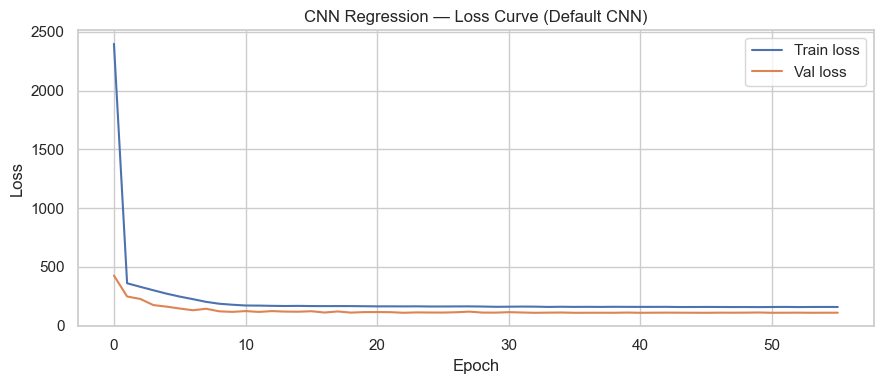

In [7]:
plot_loss_curve(
    best_reg['history'],
    f"CNN Regression — Loss Curve ({best_reg['label']})",
    f'{OUT_DIR}/figures/reg_loss_curve.png'
)

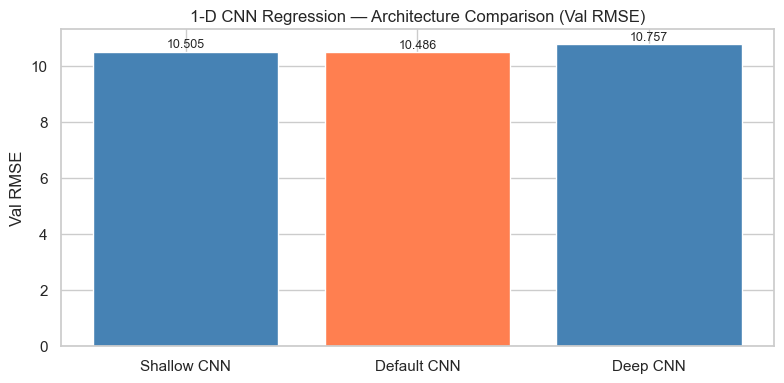

In [8]:
labels    = [r['label']    for r in reg_results]
val_rmses = [r['val_rmse'] for r in reg_results]
colors    = ['coral' if l == best_reg['label'] else 'steelblue' for l in labels]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, val_rmses, color=colors)
plt.ylabel('Val RMSE')
plt.title('1-D CNN Regression — Architecture Comparison (Val RMSE)')
for bar, v in zip(bars, val_rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_arch_comparison.png', dpi=150)
plt.show()

In [9]:
cnn_reg.eval()
with torch.no_grad():
    y_reg_pred = cnn_reg(
        torch.tensor(X_test.values, dtype=torch.float32).unsqueeze(2).to(DEVICE)
    ).cpu().numpy().flatten()

rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae  = mean_absolute_error(y_reg_test, y_reg_pred)
r2   = r2_score(y_reg_test, y_reg_pred)

print('─' * 35)
print(f'  RMSE : {rmse:.3f}')
print(f'  MAE  : {mae:.3f}')
print(f'  R²   : {r2:.4f}')
print('─' * 35)

───────────────────────────────────
  RMSE : 10.636
  MAE  : 8.754
  R²   : 0.1830
───────────────────────────────────


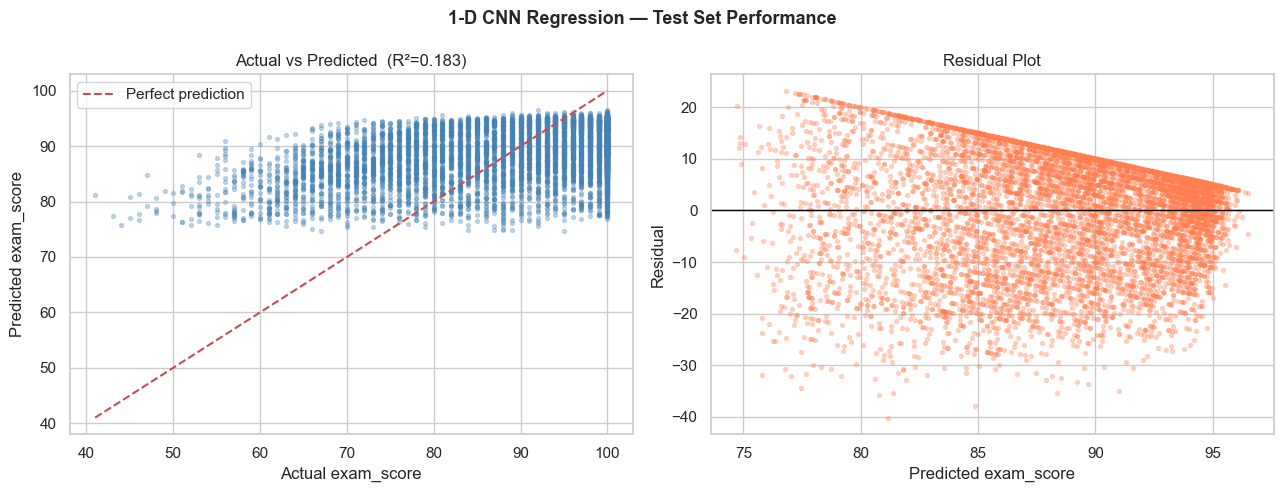

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.3, s=8, color='steelblue')
lims = [y_reg_test.min(), y_reg_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual exam_score')
axes[0].set_ylabel('Predicted exam_score')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})')
axes[0].legend()

residuals = y_reg_test.values - y_reg_pred
axes[1].scatter(y_reg_pred, residuals, alpha=0.3, s=8, color='coral')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted exam_score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.suptitle('1-D CNN Regression — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_actual_vs_predicted.png', dpi=150)
plt.show()

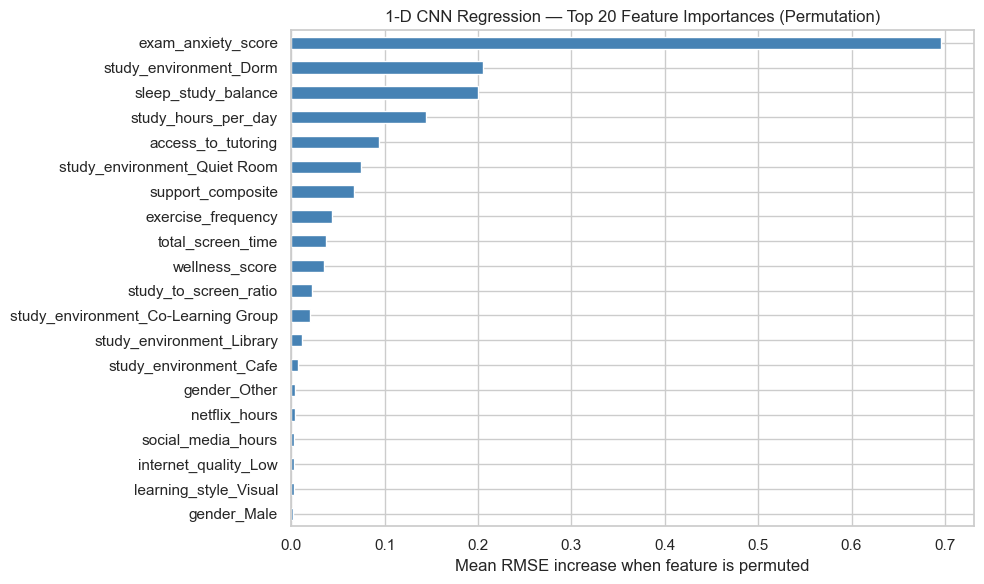

In [11]:
class CNNSklearnRegWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model
    def fit(self, X, y):
        return self
    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32).unsqueeze(2).to(DEVICE)
            return self.model(t).cpu().numpy().flatten()

perm = permutation_importance(
    CNNSklearnRegWrapper(cnn_reg),
    X_test.values, y_reg_test.values,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='neg_root_mean_squared_error'
)

importances = pd.Series(perm.importances_mean, index=feature_names)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Mean RMSE increase when feature is permuted')
plt.title('1-D CNN Regression — Top 20 Feature Importances (Permutation)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_feature_importances.png', dpi=150)
plt.show()

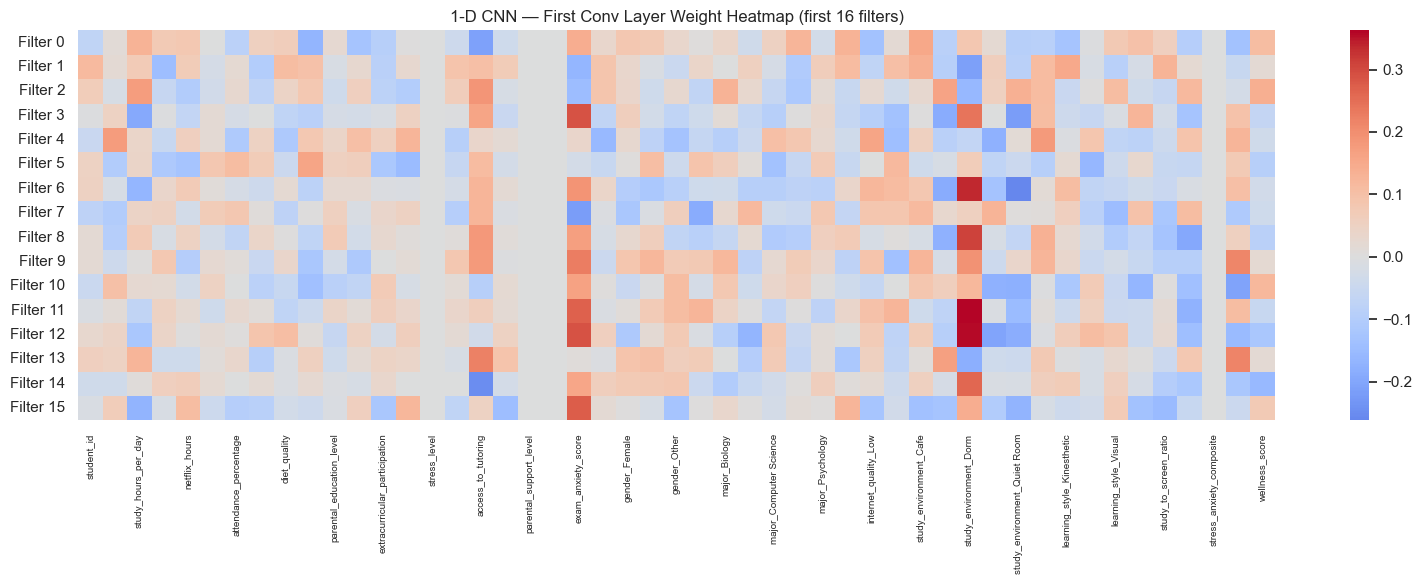

In [12]:
# First Conv1d layer weights: shape (out_channels, in_channels, kernel_size)
first_conv = [m for m in cnn_reg.conv.modules() if isinstance(m, nn.Conv1d)][0]
weights = first_conv.weight.detach().cpu().numpy()[:, :, 0]  # (out_ch, in_ch)

n_filters_to_show = min(16, weights.shape[0])
w_subset = weights[:n_filters_to_show, :]

# Limit feature labels for readability
feat_labels = feature_names if len(feature_names) <= 40 else [
    f if i % (len(feature_names)//20) == 0 else '' for i, f in enumerate(feature_names)
]

plt.figure(figsize=(max(14, len(feature_names)//3), 6))
sns.heatmap(
    w_subset,
    cmap='coolwarm', center=0,
    xticklabels=feat_labels,
    yticklabels=[f'Filter {i}' for i in range(n_filters_to_show)],
    linewidths=0.0
)
plt.xticks(rotation=90, fontsize=7)
plt.title(f'1-D CNN — First Conv Layer Weight Heatmap (first {n_filters_to_show} filters)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_conv_weight_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
torch.save(cnn_reg.state_dict(), f'{OUT_DIR}/models/cnn_reg.pt')
print('Regression CNN saved.')

Regression CNN saved.


---
## Results Summary

In [14]:
summary = pd.DataFrame([
    {
        'Task':         'Regression (exam_score)',
        'Best Config':  best_reg['label'],
        'Test RMSE':    f'{rmse:.3f}',
        'Test MAE':     f'{mae:.3f}',
        'Test R²':      f'{r2:.4f}',
        'Test Acc':     '—',
        'Test F1':      '—',
        'Test AUC':     '—',
    }
])
display(summary)

print('\nAll figures saved to:', f'{OUT_DIR}/figures/')
print('All models saved to: ', f'{OUT_DIR}/models/')

,Task,Best Config,Test RMSE,Test MAE,Test R²,Test Acc,Test F1,Test AUC
0,Regression (exam_score),Default CNN,10.636,8.754,0.1830,—,—,—



All figures saved to: ../project/outputs/cnn/figures/
All models saved to:  ../project/outputs/cnn/models/
